In [1]:
from __future__ import annotations

import json
import platform
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import fastf1
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Use only completed seasons for the final holdout. Change these if desired.
START_YEAR = 2018
END_YEAR = 2025
TEST_YEAR = 2025

# Set True only when you intentionally want to refresh data from FastF1.
FORCE_DOWNLOAD = False

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "fastf1_cache"
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
for directory in (CACHE_DIR, DATA_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_DIR / f"fastf1_race_level_{START_YEAR}_{END_YEAR}.csv"
MODEL_PATH = ARTIFACT_DIR / "f1_module1_race_models.joblib"

fastf1.Cache.enable_cache(str(CACHE_DIR))
sns.set_theme(style="whitegrid")

print("Python:", platform.python_version())
print("FastF1:", fastf1.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)


Python: 3.14.3
FastF1: 3.8.3
scikit-learn: 1.8.0
XGBoost: 3.2.0
LightGBM: 4.6.0


In [3]:
WEATHER_COLUMNS = [
    "AirTemp", "Humidity", "Pressure", "Rainfall",
    "TrackTemp", "WindDirection", "WindSpeed",
]

In [4]:
from fastf1.ergast import Ergast


def safe_float(value, default=np.nan):
    try:
        value = float(value)
        return default if value == -1 else value
    except (TypeError, ValueError):
        return default


def first_existing(mapping, names, default=None):
    for name in names:
        if name in mapping and pd.notna(mapping[name]):
            return mapping[name]
    return default


In [5]:
def collect_fastf1_dataset(start_year: int, end_year: int) -> pd.DataFrame:
    """Collect completed race results with roughly one request per season."""
    rows = []
    today = pd.Timestamp.now(tz="UTC").tz_localize(None)
    ergast = Ergast(result_type="pandas", auto_cast=True, limit=1000)

    for year in range(start_year, end_year + 1):
        print(f"Downloading season {year} ...")
        try:
            response = ergast.get_race_results(season=year, limit=1000)
        except Exception as exc:
            if "500 calls/h" in str(exc) or "RateLimit" in type(exc).__name__:
                raise RuntimeError(
                    "FastF1's hourly request counter is already exhausted in this "
                    "kernel. Restart the Jupyter kernel, wait for the hourly limit "
                    "to reset if necessary, and run from the top. This revised "
                    "collector needs only about one request per season."
                ) from exc
            raise

        descriptions = pd.DataFrame(response.description).reset_index(drop=True)
        contents = response.content

        if len(descriptions) != len(contents):
            raise RuntimeError(
                f"Unexpected FastF1 response for {year}: "
                f"{len(descriptions)} races but {len(contents)} result tables."
            )

        for race_index, result_table in enumerate(contents):
            race_info = descriptions.iloc[race_index]
            event_date = pd.to_datetime(
                first_existing(race_info, ["raceDate", "date"]),
                errors="coerce",
            )
            if pd.isna(event_date) or event_date > today:
                continue

            event_name = str(
                first_existing(race_info, ["raceName"], f"Round {race_index + 1}")
            )
            round_number = int(
                first_existing(race_info, ["round"], race_index + 1)
            )
            location = str(
                first_existing(
                    race_info,
                    ["locality", "circuitName", "circuitId"],
                    event_name,
                )
            )
            country = str(first_existing(race_info, ["country"], "Unknown"))

            results = pd.DataFrame(result_table)
            for _, result in results.iterrows():
                position = safe_float(
                    first_existing(result, ["position", "resultPosition"])
                )
                if pd.isna(position):
                    continue

                driver = str(
                    first_existing(
                        result,
                        ["driverCode", "driverId"],
                        "Unknown",
                    )
                )
                team = str(
                    first_existing(
                        result,
                        ["constructorName", "constructorId"],
                        "Unknown",
                    )
                )
                grid = safe_float(
                    first_existing(result, ["grid", "gridPosition"])
                )
                points = safe_float(
                    first_existing(result, ["points"], 0.0),
                    default=0.0,
                )

                rows.append(
                    {
                        "season": int(year),
                        "round": round_number,
                        "event_date": event_date,
                        "event_name": event_name,
                        "country": country,
                        "location": location,
                        "event_format": "conventional",
                        "driver": driver,
                        "driver_number": str(
                            first_existing(
                                result,
                                ["driverNumber", "number"],
                                "",
                            )
                        ),
                        "team": team,
                        "grid_position": grid,
                        "finish_position": position,
                        "points": points,
                        "status": str(
                            first_existing(result, ["status"], "Unknown")
                        ),
                        "winner": int(position == 1),
                        "podium": int(position <= 3),
                    }
                )

        print(f"  Collected {sum(row['season'] == year for row in rows):,} rows")

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise RuntimeError("No FastF1 race data was collected.")
    return frame.sort_values(
        ["event_date", "season", "round", "finish_position"]
    ).reset_index(drop=True)



In [6]:

if RAW_DATA_PATH.exists() and not FORCE_DOWNLOAD:
    raw = pd.read_csv(RAW_DATA_PATH, parse_dates=["event_date"])
    print(f"Loaded cached table: {RAW_DATA_PATH} ({len(raw):,} rows)")
else:
    raw = collect_fastf1_dataset(START_YEAR, END_YEAR)
    raw.to_csv(RAW_DATA_PATH, index=False)
    print(f"Saved raw table: {RAW_DATA_PATH} ({len(raw):,} rows)")

raw.head()


Loaded cached table: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/data/fastf1_race_level_2018_2025.csv (800 rows)


,season,round,event_date,event_name,country,location,event_format,driver,driver_number,team,grid_position,finish_position,points,status,winner,podium
0,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,VET,5,Ferrari,3.0,1.0,25.0,Finished,1,1
1,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,HAM,44,Mercedes,1.0,2.0,18.0,Finished,0,1
2,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,RAI,7,Ferrari,2.0,3.0,15.0,Finished,0,1
3,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,RIC,3,Red Bull,8.0,4.0,12.0,Finished,0,0
4,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,ALO,14,McLaren,10.0,5.0,10.0,Finished,0,0


In [7]:
def validate_and_clean(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()

    numeric_cols = ["grid_position", "finish_position", "points"]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Impossible values become missing and are imputed inside each training fold.
    # This avoids fitting clipping/imputation rules on future test data.
    valid_ranges = {
        "grid_position": (0, 30),       # 0 can mean pit-lane/no classified grid
        "finish_position": (1, 30),
        "points": (0, 60),
    }

    invalid_counts = {}
    for col, (low, high) in valid_ranges.items():
        invalid = data[col].notna() & ~data[col].between(low, high)
        invalid_counts[col] = int(invalid.sum())
        data.loc[invalid, col] = np.nan

    data = data.dropna(
        subset=["event_date", "driver", "team", "event_name", "finish_position"]
    )
    data = data.drop_duplicates(["season", "round", "driver"], keep="last")

    # A valid race must contain exactly one winner.
    event_cols = ["season", "round"]
    valid_events = (
        data.groupby(event_cols)["winner"].sum().loc[lambda s: s == 1].index
    )
    valid_event_set = set(valid_events)
    keep = data[event_cols].apply(tuple, axis=1).isin(valid_event_set)
    data = data.loc[keep].copy()

    print("Invalid physical values replaced with NaN:")
    print(pd.Series(invalid_counts))
    print(f"Clean rows: {len(data):,}")
    print(f"Races: {data.groupby(event_cols).ngroups}")
    return data.sort_values(
        ["event_date", "season", "round", "driver"]
    ).reset_index(drop=True)


clean = validate_and_clean(raw)
clean.describe(include="all").T.head(20)


Invalid physical values replaced with NaN:
grid_position      0
finish_position    0
points             0
dtype: int64
Clean rows: 800
Races: 41


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
season,800.0,NaN,NaN,NaN,2021.5,2018.0,2019.75,2021.5,2023.25,2025.0,2.292721
round,800.0,NaN,NaN,NaN,3.00375,1.0,2.0,3.0,4.0,6.0,1.419068
event_date,800,NaN,NaN,NaN,2021-10-22 22:51:36.000000256,2018-03-25 00:00:00,2020-03-22 00:00:00,2021-10-20 12:00:00,2023-07-21 00:00:00,2025-04-20 00:00:00,NaN
event_name,800,16,Bahrain Grand Prix,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,800,14,Bahrain,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,800,14,Sakhir,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_format,800,1,conventional,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver,800,40,GAS,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver_number,800.0,NaN,NaN,NaN,26.69625,1.0,8.0,18.0,37.25,99.0,24.844276
team,800,16,McLaren,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def add_driver_history(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["dnf"] = ~data["status"].str.contains(
        r"Finished|\+\d+ Lap", regex=True, case=False, na=False
    )
    data["dnf"] = data["dnf"].astype(int)

    group = data.groupby("driver", group_keys=False, sort=False)
    data["driver_prior_starts"] = group.cumcount()

    for source, new_name in [
        ("finish_position", "driver_avg_finish_5"),
        ("points", "driver_avg_points_5"),
        ("grid_position", "driver_avg_grid_5"),
        ("dnf", "driver_dnf_rate_5"),
    ]:
        data[new_name] = group[source].transform(
            lambda s: s.shift(1).rolling(5, min_periods=1).mean()
        )

    data["driver_prior_win_rate"] = group["winner"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )
    data["driver_prior_podium_rate"] = group["podium"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    # Driver performance at the same circuit, using only earlier editions.
    circuit_group = data.groupby(["driver", "location"], group_keys=False, sort=False)
    data["driver_circuit_avg_finish"] = circuit_group["finish_position"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )
    return data


In [9]:
def add_team_history(data: pd.DataFrame) -> pd.DataFrame:
    event_keys = ["season", "round", "event_date", "team"]
    team_race = (
        data.groupby(event_keys, as_index=False)
        .agg(
            team_race_points=("points", "sum"),
            team_best_finish=("finish_position", "min"),
            team_podiums=("podium", "sum"),
        )
        .sort_values(["event_date", "season", "round", "team"])
    )

    team_group = team_race.groupby("team", group_keys=False, sort=False)
    team_race["team_avg_points_5"] = team_group["team_race_points"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
    team_race["team_avg_best_finish_5"] = team_group["team_best_finish"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
    team_race["team_avg_podiums_5"] = team_group["team_podiums"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )

    return data.merge(
        team_race[
            event_keys
            + ["team_avg_points_5", "team_avg_best_finish_5", "team_avg_podiums_5"]
        ],
        on=event_keys,
        how="left",
        validate="many_to_one",
    )

In [10]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    featured = add_driver_history(data)
    featured = add_team_history(featured)
    featured["season_progress"] = featured["round"] / featured.groupby("season")[
        "round"
    ].transform("max")
    featured["grid_position"] = featured["grid_position"].replace(0, np.nan)
    featured["event_key"] = (
        featured["season"].astype(str)
        + "_"
        + featured["round"].astype(int).astype(str).str.zfill(2)
    )
    return featured.sort_values(
        ["event_date", "season", "round", "driver"]
    ).reset_index(drop=True)

In [11]:
model_data = engineer_features(clean)

categorical_features = [
    "driver",
    "team",
    "location",
    "country",
    "event_format",
]

numeric_features = [
    "season",
    "round",
    "season_progress",
    "grid_position",
    "driver_prior_starts",
    "driver_avg_finish_5",
    "driver_avg_points_5",
    "driver_avg_grid_5",
    "driver_dnf_rate_5",
    "driver_prior_win_rate",
    "driver_prior_podium_rate",
    "driver_circuit_avg_finish",
    "team_avg_points_5",
    "team_avg_best_finish_5",
    "team_avg_podiums_5",
]

feature_columns = categorical_features + numeric_features

print(model_data[["season", "round", "event_name"]].drop_duplicates().tail())
print("\nFeature count:", len(feature_columns))
model_data[feature_columns + ["winner", "podium"]].head()


     season  round                event_name
700    2025      1     Australian Grand Prix
720    2025      2        Chinese Grand Prix
740    2025      3       Japanese Grand Prix
760    2025      4        Bahrain Grand Prix
780    2025      5  Saudi Arabian Grand Prix

Feature count: 20


,driver,team,location,country,event_format,season,round,season_progress,grid_position,driver_prior_starts,...,driver_avg_grid_5,driver_dnf_rate_5,driver_prior_win_rate,driver_prior_podium_rate,driver_circuit_avg_finish,team_avg_points_5,team_avg_best_finish_5,team_avg_podiums_5,winner,podium
0,ALO,McLaren,Melbourne,Australia,conventional,2018,1,0.2,10.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,BOT,Mercedes,Melbourne,Australia,conventional,2018,1,0.2,15.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,ERI,Sauber,Melbourne,Australia,conventional,2018,1,0.2,17.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,GAS,Toro Rosso,Melbourne,Australia,conventional,2018,1,0.2,20.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,GRO,Haas F1 Team,Melbourne,Australia,conventional,2018,1,0.2,6.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [ ]:
available_seasons = sorted(model_data["season"].unique())
if TEST_YEAR not in available_seasons:
    TEST_YEAR = available_seasons[-1]
    print(f"Requested test season unavailable; using {TEST_YEAR}.")

In [14]:
train_data = model_data.loc[model_data["season"] < TEST_YEAR].copy()
test_data = model_data.loc[model_data["season"] == TEST_YEAR].copy()

In [15]:
if train_data["event_key"].nunique() < 20 or test_data["event_key"].nunique() < 3:
    raise ValueError("Not enough chronological races. Download more seasons.")

X_train = train_data[feature_columns]
X_test = test_data[feature_columns]

print(
    f"Train: {train_data['season'].min()}–{train_data['season'].max()}, "
    f"{train_data['event_key'].nunique()} races, {len(train_data):,} driver-race rows"
)
print(
    f"Test: {TEST_YEAR}, {test_data['event_key'].nunique()} races, "
    f"{len(test_data):,} driver-race rows"
)


Train: 2018–2024, 36 races, 700 driver-race rows
Test: 2025, 5 races, 100 driver-race rows


In [16]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
                sparse_output=True,
            ),
        ),
    ]
)


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

In [18]:
def expanding_event_cv(data: pd.DataFrame, n_splits: int = 3):
    """Map TimeSeriesSplit event folds back to driver-row indices."""
    event_order = (
        data[["event_key", "event_date"]]
        .drop_duplicates()
        .sort_values("event_date")["event_key"]
        .to_numpy()
    )
    splitter = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for train_event_idx, valid_event_idx in splitter.split(event_order):
        train_events = set(event_order[train_event_idx])
        valid_events = set(event_order[valid_event_idx])
        train_idx = np.flatnonzero(data["event_key"].isin(train_events).to_numpy())
        valid_idx = np.flatnonzero(data["event_key"].isin(valid_events).to_numpy())
        folds.append((train_idx, valid_idx))
    return folds


temporal_cv = expanding_event_cv(train_data, n_splits=3)
print(
    "Temporal folds:",
    [(len(tr), len(va)) for tr, va in temporal_cv],
)


Temporal folds: [(180, 180), (360, 180), (540, 160)]


In [19]:
def candidate_searches():
    return {
        "RandomForest": (
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
            {
                "model__n_estimators": [350, 550, 750],
                "model__max_depth": [5, 8, 12, None],
                "model__min_samples_split": [4, 8, 14],
                "model__min_samples_leaf": [2, 4, 8],
                "model__max_features": ["sqrt", 0.5, 0.8],
            },
        ),
        "XGBoost": (
            xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist",
            ),
            {
                "model__n_estimators": [250, 400, 600, 800],
                "model__max_depth": [2, 3, 4, 5],
                "model__learning_rate": [0.015, 0.03, 0.05, 0.08],
                "model__subsample": [0.65, 0.8, 0.95],
                "model__colsample_bytree": [0.6, 0.8, 1.0],
                "model__min_child_weight": [2, 5, 10],
                "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
                "model__reg_lambda": [1.0, 3.0, 8.0, 15.0],
            },
        ),
        "LightGBM": (
            lgb.LGBMClassifier(
                objective="binary",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            ),
            {
                "model__n_estimators": [250, 400, 600, 800],
                "model__learning_rate": [0.015, 0.03, 0.05, 0.08],
                "model__num_leaves": [7, 15, 31, 47],
                "model__max_depth": [-1, 3, 5, 7],
                "model__min_child_samples": [10, 20, 35, 50],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.65, 0.8, 1.0],
                "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
                "model__reg_lambda": [0.0, 1.0, 5.0, 10.0],
            },
        ),
    }


In [20]:
def tune_target(target: str, n_iter: int = 12):
    y_train = train_data[target].astype(int)
    searches = {}
    leaderboard = []

    for name, (estimator, params) in candidate_searches().items():
        print(f"\nTuning {target}: {name}")
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", estimator),
            ]
        )
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=params,
            n_iter=n_iter,
            scoring="neg_log_loss",
            n_jobs=-1,
            cv=temporal_cv,
            refit=True,
            random_state=RANDOM_STATE,
            verbose=1,
            return_train_score=True,
        )
        started = time.time()
        search.fit(X_train, y_train)
        elapsed = time.time() - started

        cv_results = pd.DataFrame(search.cv_results_)
        best_row = cv_results.loc[search.best_index_]
        train_logloss = -float(best_row["mean_train_score"])
        valid_logloss = -float(best_row["mean_test_score"])
        overfit_gap = valid_logloss - train_logloss

        searches[name] = search
        leaderboard.append(
            {
                "target": target,
                "model": name,
                "cv_log_loss": valid_logloss,
                "train_log_loss": train_logloss,
                "overfit_gap": overfit_gap,
                "fit_seconds": elapsed,
                "best_params": search.best_params_,
            }
        )
        print(
            f"CV log loss={valid_logloss:.5f} | "
            f"train={train_logloss:.5f} | gap={overfit_gap:.5f}"
        )

    leaderboard = pd.DataFrame(leaderboard).sort_values("cv_log_loss")
    best_name = leaderboard.iloc[0]["model"]
    print(f"\nSelected {target} model: {best_name}")
    return searches[best_name].best_estimator_, leaderboard, searches


winner_model, winner_leaderboard, winner_searches = tune_target("winner")
podium_model, podium_leaderboard, podium_searches = tune_target("podium")



Tuning winner: RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
CV log loss=0.11736 | train=0.05570 | gap=0.06166

Tuning winner: XGBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
CV log loss=0.11748 | train=0.07206 | gap=0.04542

Tuning winner: LightGBM
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/

CV log loss=0.10962 | train=0.07940 | gap=0.03021

Selected winner model: LightGBM

Tuning podium: RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
CV log loss=0.21699 | train=0.09080 | gap=0.12619

Tuning podium: XGBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
CV log loss=0.21522 | train=0.18526 | gap=0.02996

Tuning podium: LightGBM
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/

CV log loss=0.21532 | train=0.18053 | gap=0.03480

Selected podium model: XGBoost


In [21]:

display(winner_leaderboard.drop(columns="best_params"))
display(podium_leaderboard.drop(columns="best_params"))


,target,model,cv_log_loss,train_log_loss,overfit_gap,fit_seconds
2,winner,LightGBM,0.109617,0.079403,0.030214,8.011974
0,winner,RandomForest,0.117364,0.055701,0.061663,5.667740
1,winner,XGBoost,0.117484,0.072061,0.045423,0.414776


,target,model,cv_log_loss,train_log_loss,overfit_gap,fit_seconds
1,podium,XGBoost,0.215220,0.185260,0.029961,0.514338
2,podium,LightGBM,0.215325,0.180529,0.034796,9.855224
0,podium,RandomForest,0.216987,0.090798,0.126190,3.976873


In [ ]:
def normalize_within_race(raw_probability: np.ndarray, event_keys: pd.Series):
    scored = pd.DataFrame(
        {"event_key": event_keys.to_numpy(), "raw_probability": raw_probability}
    )
    denominator = scored.groupby("event_key")["raw_probability"].transform("sum")
    scored["race_probability"] = np.where(
        denominator > 0,
        scored["raw_probability"] / denominator,
        1.0 / scored.groupby("event_key")["event_key"].transform("size"),
    )
    return scored["race_probability"].to_numpy()

In [23]:
def race_level_metrics(
    data: pd.DataFrame,
    target: str,
    probabilities: np.ndarray,
) -> dict:
    scored = data[
        ["event_key", "event_name", "driver", target]
    ].copy()
    scored["probability"] = probabilities
    scored["rank"] = scored.groupby("event_key")["probability"].rank(
        method="first", ascending=False
    )

    winners = scored.loc[scored[target] == 1]
    top1_accuracy = float((winners["rank"] == 1).mean())
    top3_capture = float((winners["rank"] <= 3).mean())

    y = scored[target].astype(int)
    return {
        "log_loss": log_loss(y, probabilities, labels=[0, 1]),
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities),
        "brier_score": brier_score_loss(y, probabilities),
        "race_top1_accuracy": top1_accuracy,
        "race_top3_capture": top3_capture,
    }


In [24]:
winner_raw = winner_model.predict_proba(X_test)[:, 1]
winner_probability = normalize_within_race(winner_raw, test_data["event_key"])

# Podium probabilities are independent probabilities and are not normalized to sum to 1.
podium_probability = podium_model.predict_proba(X_test)[:, 1]

winner_metrics = race_level_metrics(
    test_data, "winner", winner_probability
)
podium_metrics = race_level_metrics(
    test_data, "podium", podium_probability
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
evaluation = pd.DataFrame(
    [winner_metrics, podium_metrics],
    index=["winner", "podium"],
).T
display(evaluation.style.format("{:.4f}"))

,winner,podium
log_loss,0.1006,0.1588
roc_auc,0.9600,0.9788
average_precision,0.4824,0.8942
brier_score,0.0325,0.0475
race_top1_accuracy,0.4000,0.3333
race_top3_capture,1.0000,0.7333


In [26]:
scored_test = test_data[
    [
        "season", "round", "event_key", "event_name",
        "driver", "team", "grid_position",
        "finish_position", "winner", "podium",
    ]
].copy()
scored_test["winner_probability"] = winner_probability
scored_test["podium_probability"] = podium_probability
scored_test["predicted_winner_rank"] = scored_test.groupby("event_key")[
    "winner_probability"
].rank(method="first", ascending=False)

In [27]:
race_summary = (
    scored_test.sort_values(
        ["event_key", "winner_probability"], ascending=[True, False]
    )
    .groupby("event_key", as_index=False)
    .first()
    .rename(columns={"driver": "predicted_winner"})
)

In [28]:
actual_winners = (
    scored_test.loc[scored_test["winner"] == 1, ["event_key", "driver"]]
    .rename(columns={"driver": "actual_winner"})
)
race_summary = race_summary.merge(actual_winners, on="event_key", how="left")
race_summary["correct"] = (
    race_summary["predicted_winner"] == race_summary["actual_winner"]
)

In [29]:
display(
    race_summary[
        [
            "round", "event_name", "predicted_winner",
            "actual_winner", "winner_probability", "correct",
        ]
    ]
)

,round,event_name,predicted_winner,actual_winner,winner_probability,correct
0,1,Australian Grand Prix,NOR,NOR,0.495741,True
1,2,Chinese Grand Prix,NOR,PIA,0.312871,False
2,3,Japanese Grand Prix,VER,VER,0.442130,True
3,4,Bahrain Grand Prix,VER,PIA,0.310416,False
4,5,Saudi Arabian Grand Prix,VER,PIA,0.539101,False


In [30]:
def diagnostic_message(leaderboard: pd.DataFrame, target: str):
    best = leaderboard.iloc[0]
    gap = best["overfit_gap"]
    print(
        f"{target.title()} best model: {best['model']} | "
        f"train log loss={best['train_log_loss']:.4f} | "
        f"validation log loss={best['cv_log_loss']:.4f} | gap={gap:.4f}"
    )
    if gap > 0.12:
        print("Warning: noticeable overfitting gap. Expand data or strengthen regularization.")
    elif best["cv_log_loss"] > 0.35 and target == "winner":
        print("Possible underfitting/weak signal. Add reliable pre-race features.")
    else:
        print("No large train-validation gap detected by this diagnostic.")


diagnostic_message(winner_leaderboard, "winner")
diagnostic_message(podium_leaderboard, "podium")

Winner best model: LightGBM | train log loss=0.0794 | validation log loss=0.1096 | gap=0.0302
No large train-validation gap detected by this diagnostic.
Podium best model: XGBoost | train log loss=0.1853 | validation log loss=0.2152 | gap=0.0300
No large train-validation gap detected by this diagnostic.


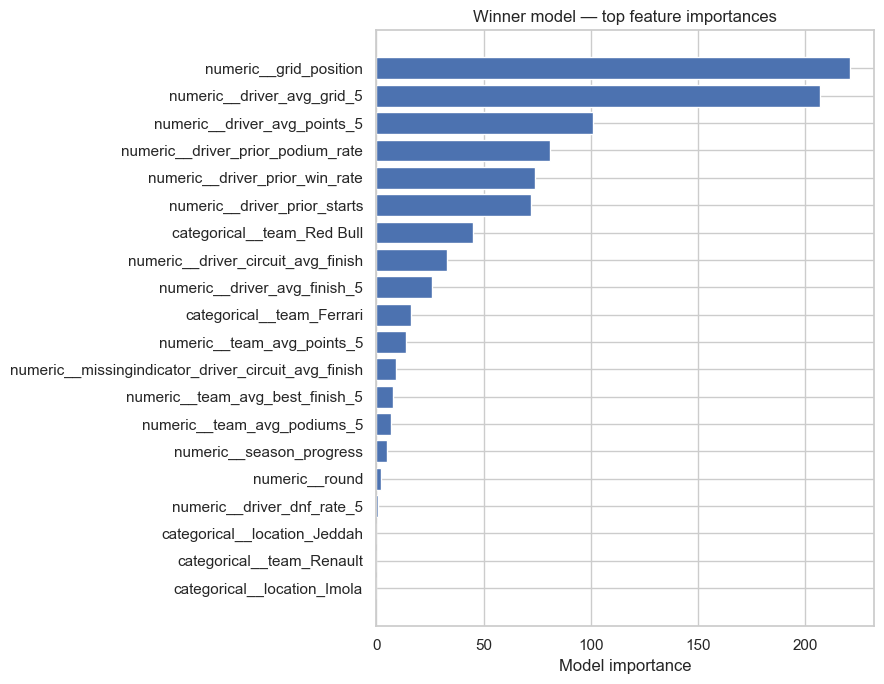

In [31]:
def plot_feature_importance(fitted_pipeline: Pipeline, title: str, top_n: int = 20):
    transformer = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    feature_names = transformer.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        importance = np.asarray(model.feature_importances_)
    else:
        print("Selected model has no built-in feature_importances_.")
        return

    importance_frame = (
        pd.DataFrame({"feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .sort_values("importance")
    )
    plt.figure(figsize=(9, 7))
    plt.barh(importance_frame["feature"], importance_frame["importance"])
    plt.title(title)
    plt.xlabel("Model importance")
    plt.tight_layout()
    plt.show()


plot_feature_importance(winner_model, "Winner model — top feature importances")

In [32]:
# The holdout metrics above remain the honest final estimate.
# Now refit the selected configurations on all available completed races for deployment.
X_all = model_data[feature_columns]
y_winner_all = model_data["winner"].astype(int)
y_podium_all = model_data["podium"].astype(int)

winner_model.fit(X_all, y_winner_all)
podium_model.fit(X_all, y_podium_all)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [33]:
artifact = {
    "winner_model": winner_model,
    "podium_model": podium_model,
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "winner_metrics_unseen_season": winner_metrics,
    "podium_metrics_unseen_season": podium_metrics,
    "winner_model_name": winner_leaderboard.iloc[0]["model"],
    "podium_model_name": podium_leaderboard.iloc[0]["model"],
    "winner_best_params": winner_leaderboard.iloc[0]["best_params"],
    "podium_best_params": podium_leaderboard.iloc[0]["best_params"],
    "training_years": [int(model_data["season"].min()), int(model_data["season"].max())],
    "holdout_year": int(TEST_YEAR),
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "package_versions": {
        "fastf1": fastf1.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
        "lightgbm": lgb.__version__,
        "joblib": joblib.__version__,
    },
}


In [34]:
joblib.dump(artifact, MODEL_PATH, compress=3)
print(f"Saved model bundle to: {MODEL_PATH.resolve()}")
print(f"Artifact size: {MODEL_PATH.stat().st_size / 1_000_000:.2f} MB")

Saved model bundle to: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/f1_module1_race_models.joblib
Artifact size: 0.12 MB


In [35]:
loaded = joblib.load(MODEL_PATH)

In [37]:
def predict_prepared_race(field: pd.DataFrame, loaded_artifact: dict) -> pd.DataFrame:
    """Predict a field whose rows already contain the notebook's pre-race features."""
    features = loaded_artifact["feature_columns"]
    missing = sorted(set(features) - set(field.columns))
    if missing:
        raise ValueError(f"Missing required pre-race features: {missing}")

    winner_raw = loaded_artifact["winner_model"].predict_proba(field[features])[:, 1]
    winner_prob = winner_raw / winner_raw.sum() if winner_raw.sum() else np.repeat(
        1 / len(field), len(field)
    )
    podium_prob = loaded_artifact["podium_model"].predict_proba(field[features])[:, 1]

    output = field[["driver", "team", "grid_position"]].copy()
    output["winner_probability"] = winner_prob
    output["podium_probability"] = podium_prob
    return output.sort_values("winner_probability", ascending=False).reset_index(drop=True)

In [38]:
# Use the last race in the unseen test season as the reproducible example.
sample_event = (
    test_data[["event_key", "event_date"]]
    .drop_duplicates()
    .sort_values("event_date")
    .iloc[-1]["event_key"]
)
sample_field = test_data.loc[test_data["event_key"] == sample_event].copy()
sample_prediction = predict_prepared_race(sample_field, loaded)

actual_winner = sample_field.loc[sample_field["winner"] == 1, "driver"].iloc[0]
predicted_winner = sample_prediction.iloc[0]["driver"]
event_name = sample_field["event_name"].iloc[0]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [39]:
print(f"Sample race: {event_name} ({TEST_YEAR})")
print(f"Predicted winner: {predicted_winner}")
print(f"Actual winner:    {actual_winner}")
print(f"Correct:          {predicted_winner == actual_winner}")
display(
    sample_prediction.head(10).style.format(
        {
            "grid_position": "{:.0f}",
            "winner_probability": "{:.2%}",
            "podium_probability": "{:.2%}",
        }
    )
)

Sample race: Saudi Arabian Grand Prix (2025)
Predicted winner: VER
Actual winner:    PIA
Correct:          False


,driver,team,grid_position,winner_probability,podium_probability
0,VER,Red Bull,1,46.38%,79.41%
1,PIA,McLaren,2,37.48%,83.24%
2,RUS,Mercedes,3,8.63%,60.59%
3,NOR,McLaren,10,2.89%,21.84%
4,LEC,Ferrari,4,1.51%,42.53%
5,ANT,Mercedes,5,0.63%,13.39%
6,SAI,Williams,6,0.44%,3.40%
7,TSU,Red Bull,8,0.31%,2.69%
8,HAM,Ferrari,7,0.21%,3.34%
9,STR,Aston Martin,16,0.18%,0.91%
